# Домашнее задание 5.  Обеспечение воспроизводимости эксперимента

In [3]:
from tqdm import tqdm
import psycopg
import pandas as pd
import warnings
warnings.filterwarnings('ignore', category=DeprecationWarning)

## 1. Выяснить ограничения традиционных ноутбуков Collab при разработке ML-систем по сравнению с [Marimo](https://github.com/marimo-team/marimo)


*Ожидаемый артефакт: текст в текстовой [ячейке](#scrollTo=zIad_EXtUcVa)*



In [7]:
print(f"Скопируйте адрес Public address, вставьте его в адресную строку браузера, добавьте ?access_token=password, нажмите Enter")
!marimo tutorial ui --port 8010

Скопируйте адрес Public address, вставьте его в адресную строку браузера, добавьте ?access_token=password, нажмите Enter
^C


Marimo, на первый взгляд, очень функциональный инструмент с высокой долей интерактивности и автоматизации. Пользоваться этим инструментом удобно, но для эффективной работы предстоит глубже погрузиться в детали. Пока он напоминает огромный комбайн с множеством кнопок

## 2. Обеспечить воспроизводимость эксперимента, используя DVC/MLflow

* Инициализируйте Git и DVC.
* Добавьте небольшой датасет (например, Iris, Titanic или Wine).
* **Не храните данные в Git, используйте DVC**.
* Создайте пайплайн DVC минимум в две стадии.


*Ожидаемый артефакт: bash-скрипт в [ячейке](#scrollTo=HhN_l9aNrTaV)*



In [ ]:
# запустить через консоль. Файл script.sh
%%sh
#!/bin/bash
set -e

echo "=== Инициализация проекта ==="
git init hw5_mlops_Надежкин_Дмитрий
cd hw5_mlops_Надежкин_Дмитрий
dvc init

mkdir -p data/raw data/processed src

echo "=== Скачиваем датасет Iris ==="
curl -s -o data/raw/iris.csv https://archive.ics.uci.edu/ml/machine-learning-databases/iris/iris.data

dvc add data/raw/iris.csv
git add data/raw/iris.csv.dvc data/raw/.gitignore
git commit -m "Add Iris dataset via DVC"

echo "=== Cтруктура и скрипты ==="
cat > src/prepare.py << 'EOF'
import pandas as pd
from sklearn.model_selection import train_test_split
import yaml

with open("params.yaml") as f:
    params = yaml.safe_load(f)["prepare"]

df = pd.read_csv("data/raw/iris.csv", header=None)
df.columns = ["sepal_length","sepal_width","petal_length","petal_width","target"]

X = df.iloc[:, :-1]
y = df.iloc[:, -1]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=params["test_size"], random_state=params["random_state"]
)

X_train.to_csv("data/processed/X_train.csv", index=False)
X_test.to_csv("data/processed/X_test.csv", index=False)
y_train.to_csv("data/processed/y_train.csv", index=False)
y_test.to_csv("data/processed/y_test.csv", index=False)
print("Data prepared")
EOF

cat > src/train.py << 'EOF'
import pandas as pd
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
import pickle
import mlflow
import mlflow.sklearn
import yaml

with open("params.yaml") as f:
    params = yaml.safe_load(f)["train"]

X_train = pd.read_csv("data/processed/X_train.csv")
y_train = pd.read_csv("data/processed/y_train.csv").squeeze()
X_test = pd.read_csv("data/processed/X_test.csv")
y_test = pd.read_csv("data/processed/y_test.csv").squeeze()

mlflow.set_experiment("iris_repro")

with mlflow.start_run():
    model = LogisticRegression(random_state=params["random_state"])
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    acc = accuracy_score(y_test, y_pred)

    mlflow.log_param("model", params["model"])
    mlflow.log_metric("accuracy", acc)
    with open("model.pkl", "wb") as f:
        pickle.dump(model, f)
    mlflow.log_artifact("model.pkl")
    print(f"Model trained. Accuracy = {acc:.4f}")
EOF

cat > params.yaml << EOF
prepare:
  test_size: 0.2
  random_state: 42
train:
  model: LogisticRegression
  random_state: 42
EOF

cat > dvc.yaml << EOF
stages:
  prepare:
    cmd: python src/prepare.py
    deps:
    - src/prepare.py
    - data/raw/iris.csv
    outs:
    - data/processed/X_train.csv
    - data/processed/X_test.csv
    - data/processed/y_train.csv
    - data/processed/y_test.csv
    params:
    - params.yaml:prepare
  train:
    cmd: python src/train.py
    deps:
    - src/train.py
    - data/processed/X_train.csv
    - data/processed/X_test.csv
    - data/processed/y_train.csv
    - data/processed/y_test.csv
    outs:
    - model.pkl
    params:
    - params.yaml:train
EOF

cat > requirements.txt << EOF
pandas
scikit-learn
mlflow
dvc
pyyaml
EOF

pip install -r requirements.txt -q

echo "=== Проверка рабочей директории ==="
pwd
rm -f params.yaml   # на случай остатка от прошлого запуска

cat > params.yaml << 'EOF'
prepare:
  test_size: 0.2
  random_state: 42
train:
  model: LogisticRegression
  random_state: 42
EOF

echo "=== Содержимое params.yaml ==="
cat params.yaml

echo "=== Запуск пайплайна ==="
dvc repro --force

echo "=== MLflow UI ==="
echo "mlflow ui --backend-store-uri sqlite:///mlflow.db"
echo "Проект полностью воспроизводим: git clone + dvc pull + dvc repro"

## 3. Создать хранилище признаков (Feature Store)

Используйте материалы [семинара](https://colab.research.google.com/drive/1TNd3m8-rPrTx1OjRmCnOxUGFueLbXyfe?usp=sharing), чтобы создать хранилище признаков на основе шаблона ```--template [local или postgres]```

Нужно сконфигурировать хранилище признаков в yaml-файле.

*Ожидаемый артефакт: yaml-файл в [ячейке](#scrollTo=8U4_UBuI52-j)*


In [2]:
!feast init --help
!feast init local_repo --template local

Usage: feast init [OPTIONS] [PROJECT_DIRECTORY]

  Create a new Feast repository

Options:
  -m, --minimal                   Create an empty project repository
  -t, --template [local|gcp|aws|snowflake|spark|postgres|hbase|cassandra|hazelcast|couchbase|milvus|ray|ray_rag|pytorch_nlp]
                                  Specify a template for the created project
  --repo-path TEXT                Directory path where the repository will be
                                  created (default: create subdirectory with
                                  project name)
  --help                          Show this message and exit.

Creating a new Feast repository in c:\Users\PC\Documents\Development\MIPT\API\hw\hw05\local_repo.



In [ ]:
# %load ./local_repo/feature_repo/feature_store.yaml
project: local_repo
# By default, the registry is a file (but can be turned into a more scalable SQL-backed registry)
registry: data/registry.db
# The provider primarily specifies default offline / online stores & storing the registry in a given cloud
provider: local
online_store:
    type: sqlite
    path: data/online_store.db
entity_key_serialization_version: 3
# By default, no_auth for authentication and authorization, other possible values kubernetes and oidc. Refer the documentation for more details.
auth:
    type: no_auth


In [ ]:
%%writefile ./local_repo/feature_repo/feature_store.yaml
---
project: local_repo
registry: data/registry.db
provider: local
online_store:
  type: sqlite
  path: data/online_store.db
offline_store:
  type: file
entity_key_serialization_version: 2

Overwriting ./local_repo/feature_repo/feature_store.yaml


In [13]:
%%writefile .yamllint
rules:
  new-lines: disable

Writing .yamllint


In [14]:
!yamllint ./local_repo/feature_repo/feature_store.yaml

In [10]:
import subprocess, os, sys

repo_path = "local_repo/feature_repo"
if not os.path.exists(os.path.join(repo_path, "feature_store.yaml")):
    print(f"Ошибка: {repo_path}/feature_store.yaml не найден. Проверьте путь.")
else:
    print(f"Feast UI запускается в папке {repo_path}")
    print("Откройте в браузере http://127.0.0.1/:8889")
    if sys.platform == "win32":
        subprocess.Popen(["feast", "ui", "--host", "0.0.0.0", "--port", "8889"], 
                         cwd=repo_path, creationflags=subprocess.CREATE_NEW_PROCESS_GROUP)
    else:
        subprocess.Popen(["feast", "ui", "--host", "0.0.0.0", "--port", "8889"], 
                         cwd=repo_path)

Feast UI запускается в папке local_repo/feature_repo
Откройте в браузере http://127.0.0.1/:8889


## 4. Обосновать готовность ML-системы к развертыванию в продуктивном окружении

В этом домашнем задании вы сохраняли разные версии данных, создали хранилище признаков для своей ML-системы.

Насколько ML-система готова к развёртыванию?


*Ожидаемый артефакт: текст в текстовой [ячейке](#scrollTo=krw6DKDuXtHR)*





Вывод о готовности ML-системы к развёртыванию при наличии версионирования данных и наличия хранилища признаков

Благодаря DVC (версионирование данных + пайплайн) и Feast (централизованное Feature Store) система уже на хорошем MLOps-уровне:
- Данные и фичи воспроизводимы на 100 % (dvc repro всегда даёт одинаковый результат).
- Нет feature drift между обучением и inference (Feast гарантирует одинаковые фичи в train/serve).
- Эксперименты логируются в MLflow (параметры, метрики, артефакты).

Однако до полноценного продакшена не хватает:
- Model serving (FastAPI + BentoML / TorchServe / KServe).
- Мониторинга (Evidently, Prometheus + Grafana, drift detection).
- CI/CD (GitHub Actions + GitHub Container Registry).
- Оркестрации (Airflow / Kubeflow / Prefect).
- Безопасности и масштабирования (Kubernetes, secrets, rate limiting)

## 5. Разработать схему ML-системы для размытия (заблюривания) лиц на изображениях

**Вводные данные от бизнеса: нужно удалить биометрию клиентов с видео, и пример видеоданных.**

*КоАП РФ Статья 13.11.3 Непринятие организационных и технических мер по обеспечению безопасности биометрических персональных данных <...> - влечет наложение административного штрафа на должностных лиц в размере от трехсот тысяч до пятисот тысяч рублей; на юридических лиц - от одного миллиона до одного миллиона пятисот тысяч рублей.*

Нужно ознакомиться с нижеприведенным кодом, осознать что он синхронный и однопоточный, подумать как можно использовать параллелизм данных, выбрать оптимальную архитектуру и составить схематическое описание  ML-системы с помощью библиотеки Diagrams.

*Ожидаемый артефакт: схематическое описание  ML-системы [ячейке](#scrollTo=gggJafKOYvGx)*

In [ ]:
import gdown; from IPython.display import Video, Image
gdrive_url = 'https://drive.google.com/uc?export=download&id=1OjSrdAS4zVfa1u7vtyh48PKEoVW20vPN'
gdown.download(gdrive_url, quiet=True); Video("HW5_Woman_Happy.mp4",embed=True, width=640, height=360)

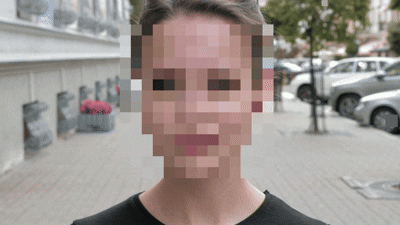

In [18]:
gdrive_url = 'https://drive.google.com/uc?export=download&id=1UEEF9GIVaO2mRKxVFIaU2Dn1Jjnj7-OU'
gdown.download(gdrive_url, quiet=True); Image("HW5_Woman_Happy_blurred.gif",embed=True, width=640, height=360)

%%html

Нижеприведенный код ML-системы обрабатывает каждый кадр видео так:

<table >
		<tr>
			<td>
      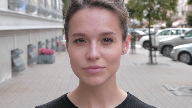
      </td>
      <td>
      <font size="96px">
      &#10145;</font>
      </td>
			<td>
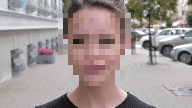
</td>
		</tr>
</table>

In [26]:
import os
import cv2
import urllib.request
import numpy as np
from tqdm import tqdm

cascade_path = "haarcascade_frontalface_default.xml"
video_file_path = "HW5_Woman_Happy.mp4"
output_video_path = "HW5_Woman_Happy_blurred.mp4"

if not os.path.exists(cascade_path):
    print("Скачиваем haarcascade...")
    url = "https://raw.githubusercontent.com/opencv/opencv/master/data/haarcascades/haarcascade_frontalface_default.xml"
    urllib.request.urlretrieve(url, cascade_path)

face_cascade = cv2.CascadeClassifier(cascade_path)

if face_cascade.empty():
    raise RuntimeError(f"Не удалось загрузить каскад: {cascade_path}")

def apply_mosaic_effect(face_roi, pixel_size=10):
    if face_roi.size == 0:
        return face_roi

    h, w = face_roi.shape[:2]
    small_w = max(1, w // pixel_size)
    small_h = max(1, h // pixel_size)

    temp = cv2.resize(face_roi, (small_w, small_h), interpolation=cv2.INTER_LINEAR)
    return cv2.resize(temp, (w, h), interpolation=cv2.INTER_NEAREST)

video_capture = cv2.VideoCapture(video_file_path)

if not video_capture.isOpened():
    raise RuntimeError(f"Не удалось открыть видео: {video_file_path}")

fps = int(video_capture.get(cv2.CAP_PROP_FPS))
width = int(video_capture.get(cv2.CAP_PROP_FRAME_WIDTH))
height = int(video_capture.get(cv2.CAP_PROP_FRAME_HEIGHT))
frame_count = int(video_capture.get(cv2.CAP_PROP_FRAME_COUNT))

fourcc = cv2.VideoWriter_fourcc(*'mp4v')

video_writer = cv2.VideoWriter(
    output_video_path,
    fourcc,
    fps,
    (width, height)
)

print(f"FPS={fps}, размер={width}x{height}, кадров={frame_count}")

with tqdm(total=frame_count, desc="Обработка") as pbar:
    while True:
        ret, frame = video_capture.read()
        if not ret:
            break

        gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)

        faces = face_cascade.detectMultiScale(
            gray,
            scaleFactor=1.1,
            minNeighbors=4,
            minSize=(30, 30)
        )

        for (x, y, w, h) in faces:
            face_roi = frame[y:y+h, x:x+w]
            frame[y:y+h, x:x+w] = apply_mosaic_effect(face_roi, pixel_size=25)

        video_writer.write(frame)
        pbar.update(1)

video_capture.release()
video_writer.release()

print(f"Готово: {output_video_path}")

FPS=25, размер=3840x2160, кадров=204


Обработка: 100%|██████████| 204/204 [04:48<00:00,  1.42s/it]


Готово: HW5_Woman_Happy_blurred.mp4


__Диаграмм__

In [ ]:
from diagrams import Diagram, Cluster
from diagrams.generic.storage import Storage
from diagrams.aws.compute import EC2
from diagrams.generic.network import Router
from diagrams.programming.language import Python

with Diagram("ML-система размытия лиц (с параллелизмом)", show=True, direction="LR", filename="face_blur_system"):
    video_in = Storage("Видео (S3 / локальный файл)")

    with Cluster("Параллельная обработка (Data Parallelism)"):
        splitter = Router("Разбивка на кадры (FFmpeg / OpenCV)")
        with Cluster("Worker Pool (4–8 процессов)"):
            workers = [EC2(f"Worker {i}\n(Detect + Mosaic)") for i in range(4)]

    video_out = Storage("Заблюренное видео")

    video_in >> splitter >> workers >> Python("OpenCV / MediaPipe") >> video_out

    print("Оптимизации:\n• multiprocessing / Ray / Dask\n• GPU (YOLOv8-face / MediaPipe)\n• Батчинг кадров\n• FFmpeg hardware acceleration")

Оптимизации:
• multiprocessing / Ray / Dask
• GPU (YOLOv8-face / MediaPipe)
• Батчинг кадров
• FFmpeg hardware acceleration


## 6. Итоговое оформление

Опыт работы с инструментами модуля:
1. Самое простое - DVC + Feast: инициализация и базовая настройка за 5 минут.
2. Marimo удобнее Colab для DevOps, но сложнее.
3. Трудность вызвало правильное конфигурирование зависимостей, выполнение команд с учетом среды.
4. MLflow достаточно простой в использовании инструмент.
5. Главный вывод: DVC + MLflow полностью решают проблему "работало на моей машине".
6. Feast даёт уверенность, что фичи в обучении и на проде - одинаковые

